# Lab: Support Vector Machines
*In this lab, we will apply Support Vector Machine (SVM) techniques using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
>
> * **Business Context:** Credit card fraud is a critical problem for financial institutions and payment processors, resulting in significant financial losses and eroding consumer confidence. As digital transactions become more common, the volume and sophistication of fraudulent activity continue to increase, challenging traditional detection methods.
> * **Business Problem:** The current approach to identifying fraudulent transactions is largely reactive and relies on static rules or manual review. This results in delayed detection, increased operational costs, and dissatisfied customers who experience either false alarms or undetected fraudulent charges on their accounts.
> * **Project Goal:** The objective of this project is to enable the early and accurate identification of fraudulent credit card transactions within a large volume of real-time payments. By moving from manual processes and fixed rules to an automated, data-driven system, the business aims to minimize financial losses, improve operational efficiency, and enhance the customer experience.
> * **Business Impact:** A successful solution would allow the company to:
>   - Prevent significant monetary losses caused by undetected fraudulent activity.
>   - Respond rapidly to suspicious transactions and deploy targeted interventions.
>   - Reduce false positives, minimizing unnecessary inconvenience for legitimate customers.
>   - Strengthen trust and brand reputation in a highly competitive financial market.

---

> ### 📝 2. Analytic Approach Report (Summary)
>
> * **Problem Type:** This is a classic **supervised binary classification problem**, where each credit card transaction must be classified as either “fraudulent” or “legitimate.” The dataset is highly imbalanced, with fraudulent transactions making up only a small fraction of total records.
> * **Modeling Approach:** To address the business objective, we will develop and evaluate a machine learning model that can automate the identification of fraudulent transactions. The main focus will be on applying **Support Vector Machines (SVM)**, a powerful family of classification algorithms well-suited for separating complex, high-dimensional data, especially after proper feature scaling.
> * **Handling Class Imbalance:** Due to the extreme imbalance in the dataset, special care will be taken to ensure the model does not default to predicting the majority class (legitimate transactions). Strategies may include:
>   - Using appropriate evaluation metrics that reflect performance on the minority (fraud) class.
>   - Exploring techniques such as data resampling, class weighting, or anomaly detection methods where relevant.
> * **Evaluation Metrics:** Given the cost of false negatives (missed fraud) and false positives (legitimate transactions flagged), multiple metrics will be applied:
>   - **Recall (Sensitivity):** Primary metric, maximizing the detection rate of fraudulent transactions.
>   - **Precision:** Identifying how many flagged cases are actually fraud.
>   - **F1-Score:** Balance between precision and recall.
>   - **ROC-AUC:** Performance across thresholds.
> Overall accuracy will **not** be the main metric due to class imbalance.
> * **Validation Strategy:** The dataset will be split into training and test subsets to fairly assess model generalization. 

---

> ### 📝 3. Data Requirements Report (Summary)
>
> * **Data Source:** The lab will use the widely recognized [Credit Card Fraud Detection dataset](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), which contains real transactions made by European cardholders in September 2013. The dataset consists of 284,807 transactions, with each row representing a single credit card transaction.
> * **Features (Independent Variables):**
>   - `V1`–`V28`: Result of a PCA transformation—these are anonymized, engineered features created by applying Principal Component Analysis (PCA) to the original card transaction variables to protect confidentiality.
>   - `Time`: Seconds elapsed between each transaction and the first transaction in the dataset.
>   - `Amount`: The transaction amount.
> * **Target (Dependent Variable):** `Class`: Binary label indicating transaction status (0 = legitimate, 1 = fraudulent).
> * **Granularity & Privacy:** Each row corresponds to an individual credit card transaction. Raw, identifying information (e.g., card number, merchant, location) is not included. All advanced feature columns except "Time" and "Amount" have been anonymized using PCA to preserve privacy. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection


In [1]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib


# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1 Extraction, Transformation, Loading
The data has already been download manually and saved as `../data/raw/creditcard.csv`. For this project, no further ETL process is needed.

### 4.4. Verification

In [2]:
raw_data_path = Path("../data/raw/creditcard.csv")

# Load the final interim data and verify its contents
try:
    df_verified = pd.read_csv(raw_data_path)
    print(f"Verification successful. The following DataFrame is ready for analysis with {df_verified.shape[0]} samples and {df_verified.shape[1]} features:")
    display(df_verified.sample(5))
except Exception as e:
    print(f"An error occurred while verifying the interim data: {e}")

Verification successful. The following DataFrame is ready for analysis with 284807 samples and 31 features:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
237639,149333.0,2.012940,-1.111531,-0.497209,-0.841283,-1.222163,-0.868276,-0.823070,-0.165479,-0.096328,...,0.073017,-0.023602,0.317336,-0.113139,-0.568331,-0.479812,-0.004479,-0.026496,89.5,0
41063,40516.0,1.208319,-1.230067,1.585611,0.013655,-2.097390,0.229536,-1.463040,0.252051,0.848495,...,-0.536000,-0.685907,0.054185,0.450853,0.114823,1.072416,0.016737,0.025590,40.0,0
141837,84504.0,-1.420050,-0.066935,1.408017,2.735114,2.086630,-1.006364,0.053098,0.077296,-1.694107,...,0.224290,0.205961,0.032843,0.083194,0.172800,0.219736,0.031655,0.131384,10.0,0
250013,154680.0,2.064758,-1.285739,-0.926712,-1.080319,-0.750745,0.237188,-1.141913,0.160740,0.042838,...,0.350474,0.856067,0.041808,0.105048,-0.129089,-0.104920,-0.015887,-0.049558,69.0,0
162317,115012.0,-1.126349,0.893603,0.775370,-0.914473,2.256630,1.633690,1.081658,-0.288225,0.210285,...,0.149183,1.230704,-0.817374,-0.888650,0.835463,-0.133981,-0.391231,-0.508953,1.0,0



---

> ### 📝 4. Data Collection Report (Summary)
>
> * **Data Extraction:** The credit card transactions dataset was manually downloaded and placed in the project directory as `../data/raw/creditcard.csv`. No automated extraction was required for this lab.
> * **Transformation & Loading:** No additional data transformation or cleaning was performed at this stage. The raw file was loaded directly for analysis, preserving the original structure and content.
> * **Verification:** The raw data file was read successfully, verifying that it contains 284,807 records and 31 features, with a random sample confirming expected format and content for all columns.

---

## Stage 5: Data Understanding

### 5.1. Preparation for Exploratory Data Analysis (EDA)

In [9]:
# Copy the verified DataFrame for EDA
df_eda = df_verified.copy()

# Create useful data structures 
numeric_cols = ["Time", "Amount", "Class"]
numeric_features = ["Time", "Amount"]

# Final check for the column names, data types, null values, and memory usage
print(f"  Column names: {df_eda.columns.to_list()}")
print("  Numerical Columns Info:")
df_eda[numeric_cols].info()

  Column names: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
  Numerical Columns Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   Amount  284807 non-null  float64
 2   Class   284807 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 6.5 MB


### 5.2. Descriptive Statistics


In [10]:
# Generate the descriptive statistics for the numerical variables
stats_df = df_eda[numeric_cols].describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00,0.500857
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16,2.831026
Class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00,24.039094


- 📌 **Time:** Represents the relative timing of each transaction, not an actual timestamp. Ranges from `0` to `172,792` seconds (~48 hours), with a mean of ~94,814 seconds (~26.3 hours). Distribution is broad and relatively uniform (Coefficient of Variation ≈ 0.50). 
- 📌 **Amount:** Transaction amounts range from `0` to `25,691.16` units (currency unspecified). Most transactions are small: 25th percentile is `5.6`, median is `22`, 75th percentile is `77.17`. The distribution is highly right-skewed: the mean (`88.35`) is much higher than the median (`22`), and the CV is very high (`2.83`), suggesting the presence of large outlier amounts.
- 📌 **Class:** Maximum is `1`, minimum is `0` (binary encoded). Mean value (`0.0017`) reflects extreme class imbalance: only about 0.17% of transactions are labeled as fraud (Class = 1). 25th, 50th, and 75th percentiles all are `0` (indicating legitimate), confirming that fraud is rare. Standard deviation (`0.0415`) and coefficient of variation (`24.0`) further reflect the rarity and strong imbalance of the minority class. 

### 5.3. Univariate Analysis

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


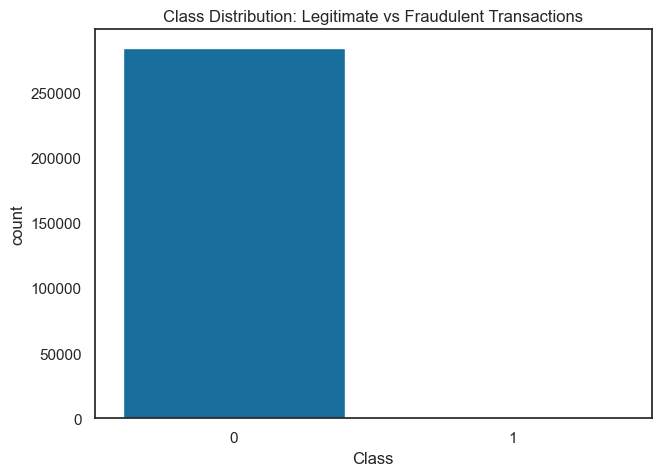

In [11]:
print(df_eda['Class'].value_counts(normalize=True))
sns.countplot(x='Class', data=df_eda)
plt.title("Class Distribution: Legitimate vs Fraudulent Transactions")
plt.show()

In [ ]:
# Visualize distribution of Time for fraud and non-fraud
sns.histplot(df_eda[df_eda['Class'] == 0]['Time'], bins=100, color='blue', label='Legitimate', kde=False, alpha=0.6)
sns.histplot(df_eda[df_eda['Class'] == 1]['Time'], bins=100, color='red', label='Fraud', kde=False, alpha=0.8)
plt.legend()
plt.title("Distribution of Transaction Time: Legitimate vs Fraudulent")
plt.xlabel("Time (seconds since first transaction)")
plt.ylabel("Transaction Count")
plt.show()